In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def main(seed):
    # --- 1. 参数设置 ---
    n = 16000#1400
    alpha = 2.75
    Rmin_mm, Rmax_mm = 0.06, 0.8
    width, height = 1024,1024 #512, 512
    L = 200 #100.0  # mm
    #seed = 4
    np.random.seed(seed)
    # --- 2. 幂律分布采样 ---
    # Inverse transform sampling
    U = np.random.rand(n)
    term1 = Rmin_mm**(1 - alpha)
    term2 = Rmax_mm**(1 - alpha)
    R_mm = (term1 + U * (term2 - term1))**(1 / (1 - alpha))
    R_mm = R_mm[R_mm <= Rmax_mm]  # Truncate

    print(f"Generated {len(R_mm)} holes. Mean R: {np.mean(R_mm):.3f} mm")

    # --- 3. 网格与 Helper 函数 ---
    x = np.linspace(0, L, width)
    y = np.linspace(0, L, height)
    XX, YY = np.meshgrid(x, y) # shape (height, width)

    def stamp_ellipse(mask, cx, cy, a_mm, b_mm, theta, xx, yy, x_ax, y_ax):
        """在 mask 上局部盖一个椭圆"""
        box = max(a_mm, b_mm)
        # 寻找局部索引 (Slicing optimization)
        x_idx = np.where((x_ax >= cx - box) & (x_ax <= cx + box))[0]
        y_idx = np.where((y_ax >= cy - box) & (y_ax <= cy + box))[0]
        
        if len(x_idx) == 0 or len(y_idx) == 0: return mask

        # 提取局部网格
        Xsub = xx[y_idx[:, None], x_idx]
        Ysub = yy[y_idx[:, None], x_idx]
        
        # 平移与旋转
        Xc, Yc = Xsub - cx, Ysub - cy
        cosT, sinT = np.cos(theta), np.sin(theta)
        Xr = cosT * Xc + sinT * Yc
        Yr = -sinT * Xc + cosT * Yc
        
        # 椭圆方程判断
        inside = (Xr/a_mm)**2 + (Yr/b_mm)**2 <= 1
        
        # 更新 Mask (局部操作)
        sub_mask = mask[y_idx[:, None], x_idx]
        sub_mask[inside] = 1
        mask[y_idx[:, None], x_idx] = sub_mask
        return mask

    def save_texture(mask, filename):
        """模拟 MATLAB 的 permute/reshape 保存格式: Header + RGBA flat"""
        # Invert mask: 0=hole, 1=tissue -> 1=hole, 0=tissue for saving? 
        # MATLAB: Anew = double(A==0). 
        Anew = (mask == 0).astype(int)
        
        # 构造 (Height, Width, 4) -> 对应 MATLAB cat(3, Anew, zeros(...,3))
        zeros = np.zeros_like(Anew)
        rgba = np.stack([Anew, zeros, zeros, zeros], axis=2) # Shape: (H, W, 4)
        
        # 对应 MATLAB permute(AAA, [3 1 2]) -> (4, H, W)
        rgba_permuted = np.transpose(rgba, (1, 0, 2))
        
        # Flatten
        data_flat = rgba_permuted.flatten()
        
        # Header: [width, height]
        header = np.array([width, height], dtype=int)
        
        # Save
        final_data = np.concatenate([header, data_flat])
        np.savetxt(filename, final_data.reshape(1, -1), delimiter=',', fmt='%d')
        print(f"Saved: {filename}")

    # --- 4. 生成 Square Mask ---
    M_sq = np.zeros((height, width))

    for r in R_mm:
        # 若要改为圆形，令 a_mm = b_mm = r 即可
        b_mm = r
        a_mm = r
        
        
        cx = a_mm + (L - 2*a_mm) * np.random.rand()
        cy = a_mm + (L - 2*a_mm) * np.random.rand()
        theta = 2 * np.pi * np.random.rand()
        
        M_sq = stamp_ellipse(M_sq, cx, cy, a_mm, b_mm, theta, XX, YY, x, y)

    # 边界墙
    M_sq[:, 0] = 1; M_sq[:, -1] = 1; M_sq[0, :] = 1; M_sq[-1, :] = 1

    # 绘图
    #plt.figure()
    #plt.imshow(M_sq, cmap='gray', origin='lower', extent=[0, L, 0, L])
    #plt.title('Square Domain')
    #plt.show()
    
    # --- 5. 生成 Circle Mask ---
    M_circ = np.zeros((height, width))
    radius_domain = 0.5 * 0.99 * L
    dist0 = np.sqrt((XX - 0.5*L)**2 + (YY - 0.5*L)**2)
    M_circ[dist0 >= radius_domain] = 1

    for r in R_mm:
        b_mm = r
        a_mm = r
        
        valid = False
        while not valid:
            cx, cy = np.random.rand() * L, np.random.rand() * L
            d_center = np.sqrt((cx - 0.5*L)**2 + (cy - 0.5*L)**2)
            if (d_center + a_mm) <= radius_domain:
                valid = True
                
        theta = 2 * np.pi * np.random.rand()
        M_circ = stamp_ellipse(M_circ, cx, cy, a_mm, b_mm, theta, XX, YY, x, y)

    plt.figure()
    plt.imshow(M_circ, cmap='gray', origin='lower', extent=[0, L, 0, L])
    plt.title('Circle Domain')
    plt.show()

    # --- 6. 保存 ---
    save_texture(M_circ, f'maskcircle_{seed}_{width}.csv')

In [ ]:
for seed in range(1, 11):
    main(seed)

开始放置孔洞 (目标: 1000)...


100%|██████████| 1000/1000 [00:00<00:00, 198650.37it/s]

放置完成：1000/1000


文件已保存至: mask_1024_1_1000.csv


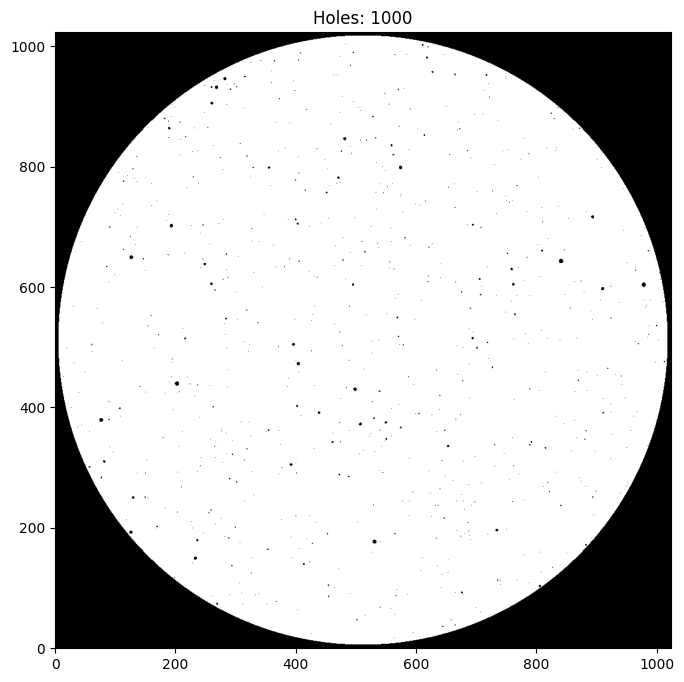

开始放置孔洞 (目标: 4000)...


100%|██████████| 4000/4000 [00:00<00:00, 138971.67it/s]

放置完成：4000/4000


文件已保存至: mask_1024_1_4000.csv


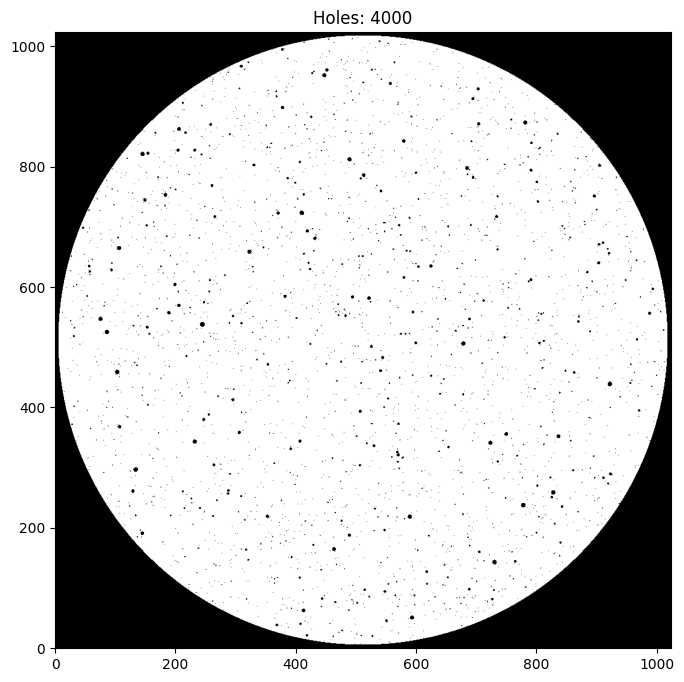

开始放置孔洞 (目标: 7000)...


100%|██████████| 7000/7000 [00:00<00:00, 145057.77it/s]

放置完成：7000/7000


文件已保存至: mask_1024_1_7000.csv


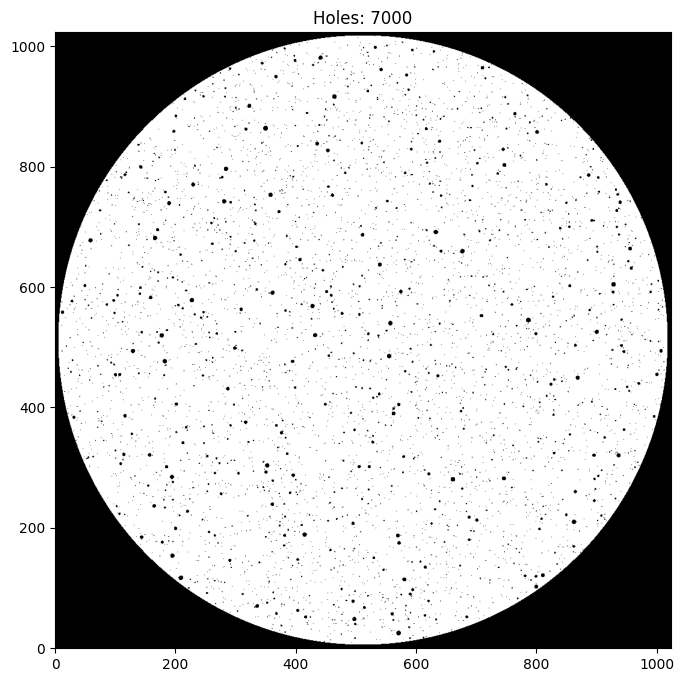

开始放置孔洞 (目标: 10000)...


100%|██████████| 10000/10000 [00:00<00:00, 152095.94it/s]

放置完成：10000/10000


文件已保存至: mask_1024_1_10000.csv


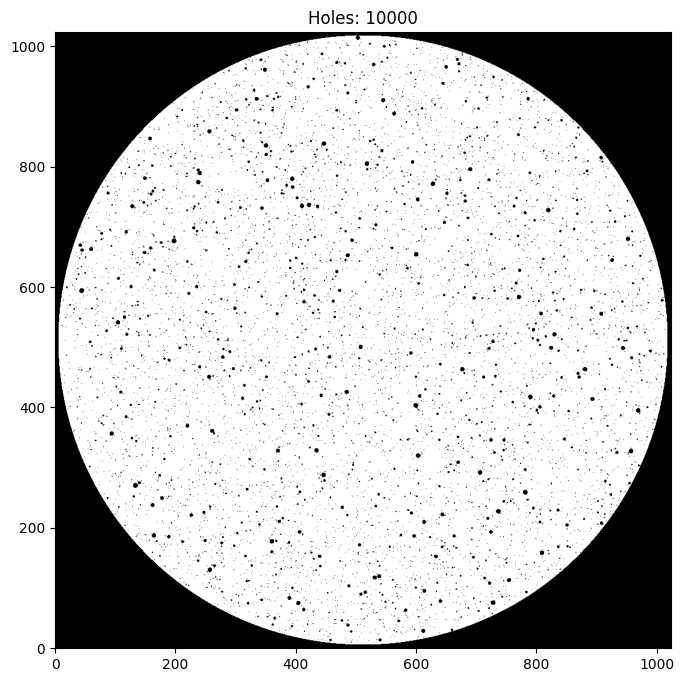

开始放置孔洞 (目标: 13000)...


100%|██████████| 13000/13000 [00:00<00:00, 125788.58it/s]

放置完成：13000/13000


文件已保存至: mask_1024_1_13000.csv


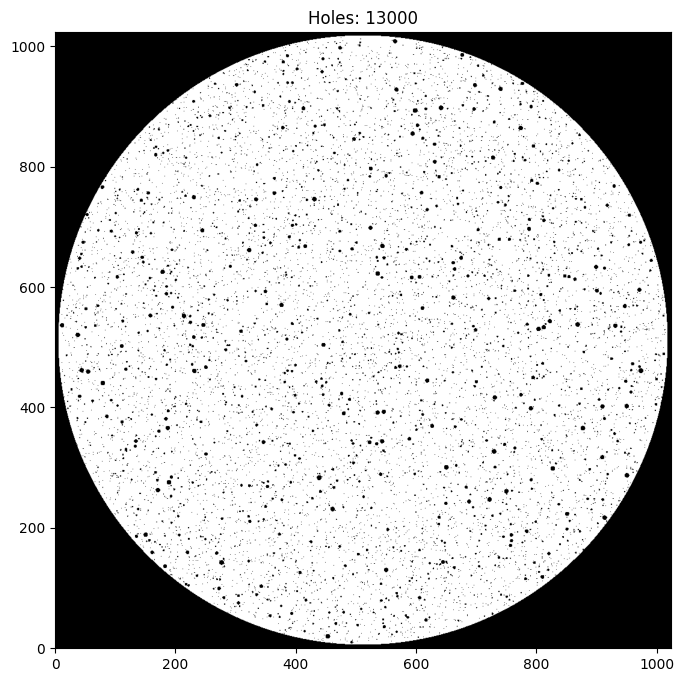

开始放置孔洞 (目标: 16000)...


100%|██████████| 16000/16000 [00:00<00:00, 132615.21it/s]

放置完成：16000/16000


文件已保存至: mask_1024_1_16000.csv


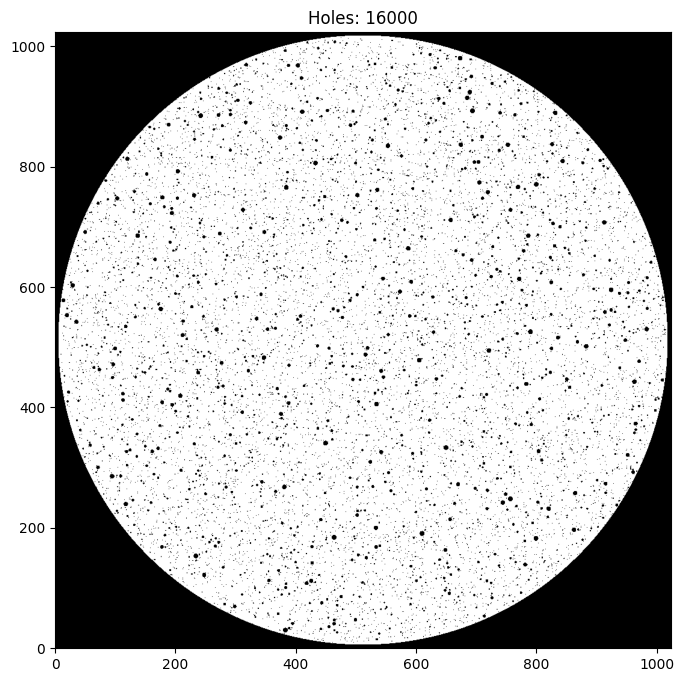

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm # 进度条库，建议安装：pip install tqdm

def main(seed=1, n_target=16000):
    # --- 1. 参数设置 ---
    L = 200.0             # 区域尺寸 200mm
    n_target = n_target      # 目标孔洞数量
    alpha = 2.75          # 幂律指数
    Rmin, Rmax = 0.06, 0.8 # 半径范围 (mm)
    grid_size = 1024      # 导出图像/数据的分辨率
    
    np.random.seed(seed)

    # --- 2. 幂律分布采样 (Inverse Transform Sampling) ---
    # 预采样略多于目标数量，以应对放置失败的情况
    U = np.random.rand(int(n_target * 1.2))
    term1 = Rmin**(1 - alpha)
    term2 = Rmax**(1 - alpha)
    R_samples = (term1 + U * (term2 - term1))**(1 / (1 - alpha))
    R_samples = R_samples[R_samples <= Rmax]
    # 按半径从大到小排序，可以提高 RSA 算法的填充效率
    R_samples = np.sort(R_samples)[::-1]

    # --- 3. 空间网格初始化 (用于加速重叠检查) ---
    # 网格单元大小略大于最大直径
    cell_size = Rmax * 2.1 
    n_cells = int(np.ceil(L / cell_size))
    # grid[i][j] 存储落在该单元格内的圆心索引
    spatial_grid = [[[] for _ in range(n_cells)] for _ in range(n_cells)]

    def get_cell_idx(px, py):
        ix = int(px / L * n_cells)
        iy = int(py / L * n_cells)
        return min(ix, n_cells-1), min(iy, n_cells-1)

    # --- 4. RSA 放置算法 (带空间索引优化) ---
    placed_circles = [] # 存储 [x, y, r]
    radius_boundary = 0.5 * 0.99 * L # 边界约束
    center_loc = 0.5 * L

    print(f"开始放置孔洞 (目标: {n_target})...")
    pbar = tqdm(total=n_target)
    
    for r in R_samples:
        if len(placed_circles) >= n_target:
            break
            
        success = False
        for _ in range(200): # 每个孔尝试次数
            cx, cy = np.random.rand() * L, np.random.rand() * L
            
            # 约束 1: 必须在大的圆形组织范围内
            dist_to_center = np.sqrt((cx - center_loc)**2 + (cy - center_loc)**2)
            if (dist_to_center + r) > radius_boundary:
                continue
                
            # 约束 2: 重叠检查 (仅检查相邻网格)
            ix, iy = get_cell_idx(cx, cy)
            overlap = False
            # 检查周围 3x3 的网格单元
            for nx in range(max(0, ix-1), min(n_cells, ix+2)):
                for ny in range(max(0, iy-1), min(n_cells, iy+2)):
                    for idx in spatial_grid[nx][ny]:
                        px, py, pr = placed_circles[idx]
                        if (cx - px)**2 + (cy - py)**2 < (r + pr)**2:
                            overlap = True
                            break
                    if overlap: break
                if overlap: break
            
            if not overlap:
                # 放置成功
                idx_now = len(placed_circles)
                placed_circles.append([cx, cy, r])
                spatial_grid[ix][iy].append(idx_now)
                success = True
                pbar.update(1)
                break
                
    pbar.close()
    print(f"放置完成：{len(placed_circles)}/{n_target}")

    # --- 5. 高效生成 Mask (矩阵化操作) ---
    mask = np.zeros((grid_size, grid_size), dtype=np.uint8)
    # 建立坐标系
    coord = np.linspace(0, L, grid_size)
    
    # 预处理大圆形边界 (1 为组织，0 为孔洞)
    XX, YY = np.meshgrid(coord, coord)
    dist_sq = (XX - center_loc)**2 + (YY - center_loc)**2
    mask[dist_sq >= radius_boundary**2] = 1

    # 绘制每个孔洞
    for cx, cy, r in placed_circles:
        # 仅在局部区域计算，大幅提升速度
        x0, x1 = cx - r, cx + r
        y0, y1 = cy - r, cy + r
        
        # 转换为像素索引
        ix0, ix1 = int(x0/L*grid_size), int(x1/L*grid_size)
        iy0, iy1 = int(y0/L*grid_size), int(y1/L*grid_size)
        
        # 边界修整
        ix0, ix1 = max(0, ix0), min(grid_size, ix1+1)
        iy0, iy1 = max(0, iy0), min(grid_size, iy1+1)
        
        # 局部掩码计算
        sub_x = coord[ix0:ix1]
        sub_y = coord[iy0:iy1]
        if len(sub_x) == 0 or len(sub_y) == 0: continue
        
        sub_XX, sub_YY = np.meshgrid(sub_x, sub_y)
        sub_dist_sq = (sub_XX - cx)**2 + (sub_YY - cy)**2
        mask[iy0:iy1, ix0:ix1][sub_dist_sq <= r**2] = 1 # 1 代表孔洞

    # --- 6. 保存与预览 ---
    save_as_csv(mask, f'mask_{grid_size}_{seed}_{n_target}.csv', grid_size)
    
    plt.figure(figsize=(8,8))
    plt.imshow(mask, cmap='gray_r', origin='lower') # 反色显示：黑色为孔洞
    plt.title(f"Holes: {len(placed_circles)}")
    plt.show()

def save_as_csv(mask, filename, size):
    """按照你要求的特定 RGBA 扁平化格式保存"""
    # 0 代表组织，1 代表孔洞 -> 你的逻辑：Anew = (mask==0)
    # 这里根据你的原始逻辑：组织部分为 1(Alpha=255)，孔洞部分为 0
    Anew = (mask == 0).astype(np.uint8) 
    # 构造 [W, H, R, G, B, A] 逻辑，但你只用了 Alpha 通道
    # 原始逻辑是 rgba_permuted 展开
    data_flat = np.zeros(size * size * 4, dtype=np.uint8)
    # 填充红色通道（按你原代码逻辑：rgba = [Anew, 0, 0, 0]）
    data_flat[0::4] = Anew.flatten() 
    
    header = np.array([size, size], dtype=int)
    final_data = np.concatenate([header, data_flat])
    np.savetxt(filename, final_data.reshape(1, -1), delimiter=',', fmt='%d')
    print(f"文件已保存至: {filename}")

if __name__ == "__main__":
    for n in range(1000,17000,3000):
        main(seed=1, n_target=n)

In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import numpy as np
import cv2

def cross_verify_correctly(csv_filename):
    # 1. 加载并还原
    data = np.loadtxt(csv_filename, delimiter=',')
    width, height = int(data[0]), int(data[1])
    img_flat = data[2:]
    # 还原为 (W, H, 4) 然后转置回 (H, W, 4)
    img_rgba = img_flat.reshape((width, height, 4)).transpose(1, 0, 2)
    
    # 2. 提取 Anew 通道 (1=组织, 0=孔/背景)
    anew_channel = img_rgba[:, :, 0]
    
    # 3. 构造背景屏蔽 (排除大圆外部)
    L = 200.0
    x = np.linspace(0, L, width)
    y = np.linspace(0, L, height)
    XX, YY = np.meshgrid(x, y)
    dist_to_center = np.sqrt((XX - 0.5*L)**2 + (YY - 0.5*L)**2)
    radius_domain = 0.5 * 0.99 * L
    
    # 核心转换：只有【在组织内】且【Anew为0】的才是孔
    # 1 代表我们要数的目标，0 代表背景
    true_holes = (anew_channel == 0) & (dist_to_center < radius_domain)
    
    # 4. 执行连通域分析
    num_labels, _ = cv2.connectedComponents(true_holes.astype(np.uint8))
    actual_count = num_labels - 1
    
    print(f"检测结果：{actual_count} 个孔洞")
    return actual_count

# 执行验证
cross_verify_correctly('mask_1.csv')

检测结果：10855 个孔洞


10855